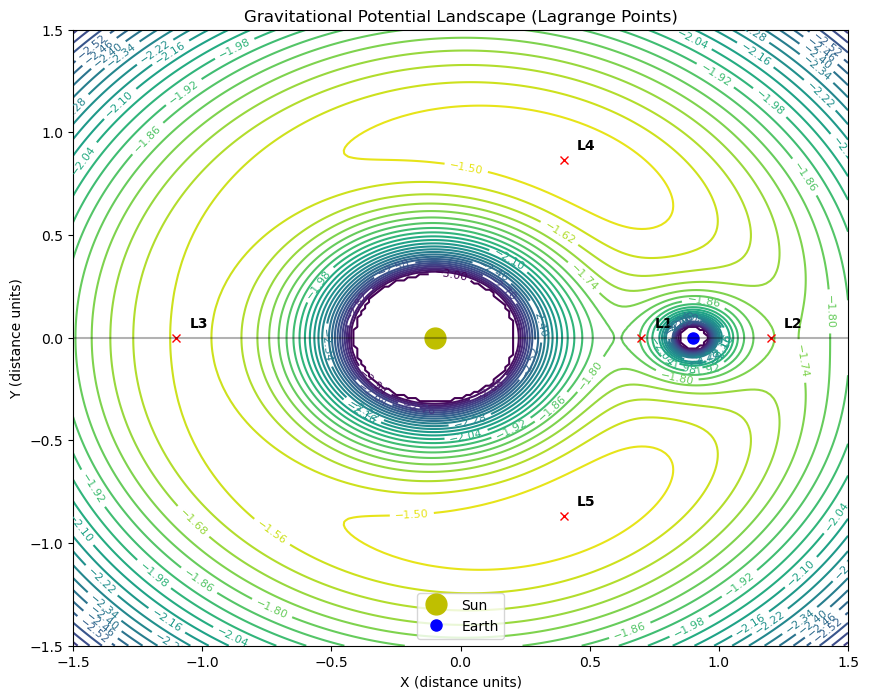

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def lagrange_demo():
    # 1. Setup constants (Mass ratio of Earth-Sun is ~0.01 for visualization)
    mu = 0.1  # Exaggerated mass ratio for clearer contours
    
    # 2. Define the grid
    x = np.linspace(-1.5, 1.5, 200)
    y = np.linspace(-1.5, 1.5, 200)
    X, Y = np.meshgrid(x, y)

    # 3. Calculate Potential Energy (Gravitational + Centrifugal)
    # r1: distance to Sun (at -mu, 0), r2: distance to Earth (at 1-mu, 0)
    r1 = np.sqrt((X + mu)**2 + Y**2)
    r2 = np.sqrt((X - (1 - mu))**2 + Y**2)
    
    # The Effective Potential Function
    # Potential = - (Mass1/r1) - (Mass2/r2) - 0.5 * (centrifugal_force)
    Z = - (1 - mu) / r1 - mu / r2 - 0.5 * (X**2 + Y**2)

    # 4. Plotting
    plt.figure(figsize=(10, 8))
    
    # Limit Z to see contours better (it goes to -infinity at the centers)
    Z_clipped = np.clip(Z, -3, -1.2)
    
    contours = plt.contour(X, Y, Z_clipped, levels=25, cmap='viridis')
    plt.clabel(contours, inline=True, fontsize=8)
    
    # Mark the Sun and Earth
    plt.plot(-mu, 0, 'yo', markersize=15, label='Sun')
    plt.plot(1 - mu, 0, 'bo', markersize=8, label='Earth')

    # Approximate Lagrange Point Locations
    # (In a real script, we'd solve the derivative=0 equations)
    points = {
        'L1': (0.7, 0), 'L2': (1.2, 0), 'L3': (-1.1, 0),
        'L4': (0.5 - mu, 0.866), 'L5': (0.5 - mu, -0.866)
    }

    for name, pos in points.items():
        plt.plot(pos[0], pos[1], 'rx')
        plt.text(pos[0] + 0.05, pos[1] + 0.05, name, fontweight='bold')

    plt.title(f"Gravitational Potential Landscape (Lagrange Points)")
    plt.xlabel("X (distance units)")
    plt.ylabel("Y (distance units)")
    plt.axhline(0, color='black', alpha=0.3)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    lagrange_demo()